# Predicción de Diabetes - Clasificación Binaria

Este notebook realiza un análisis predictivo del dataset de diabetes utilizando técnicas de machine learning. 
Se implementan algoritmos de clasificación, normalización de datos, y optimización de hiperparámetros mediante búsqueda aleatoria.

## Contenido:
1. **Importación de librerías** - Herramientas necesarias
2. **Carga y exploración de datos** - Análisis del dataset
3. **Análisis exploratorio** - Estadísticas y visualizaciones
4. **Preparación de datos** - Escalado y división
5. **Modelado y optimización** - Entrenamiento y ajuste de hiperparámetros
6. **Evaluación** - Métricas de rendimiento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importación de Librerías

Se importan las librerías esenciales para:
- **numpy**: Operaciones numéricas con arrays
- **pandas**: Manipulación de datos en DataFrames
- **matplotlib y seaborn**: Visualización de datos
- **sklearn**: Algoritmos de machine learning y preprocesamiento

In [2]:
data = pd.read_csv('data/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Carga de Datos

Cargamos el dataset de diabetes de sklearn, que contiene información médica de pacientes y si tienen diabetes (0=No, 1=Sí):

In [3]:
data.shape

(768, 9)

Verificamos la forma del dataset (número de filas y columnas):

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Mostramos información detallada del dataset: tipos de datos, valores faltantes, etc.:

In [5]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Mostramos las primeras 5 filas del dataset:

In [6]:
data_copy = data.copy()

## 3. Análisis Exploratorio

Analizamos la distribución de la variable objetivo (Outcome = 1 = tiene diabetes, 0 = no tiene):

In [7]:
data_copy.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Contamos cuántos casos positivos (diabéticos) y negativos (no diabéticos) hay:

In [8]:
data_copy.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Obtenemos los nombres de todas las columnas del dataset:

In [9]:
data_copy[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = data_copy[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

Creamos una lista con el nombre de todas las características (excluyendo la variable objetivo 'Outcome'):

In [10]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


Rellenamos los valores faltantes (NaN) con la mediana de cada columna:

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

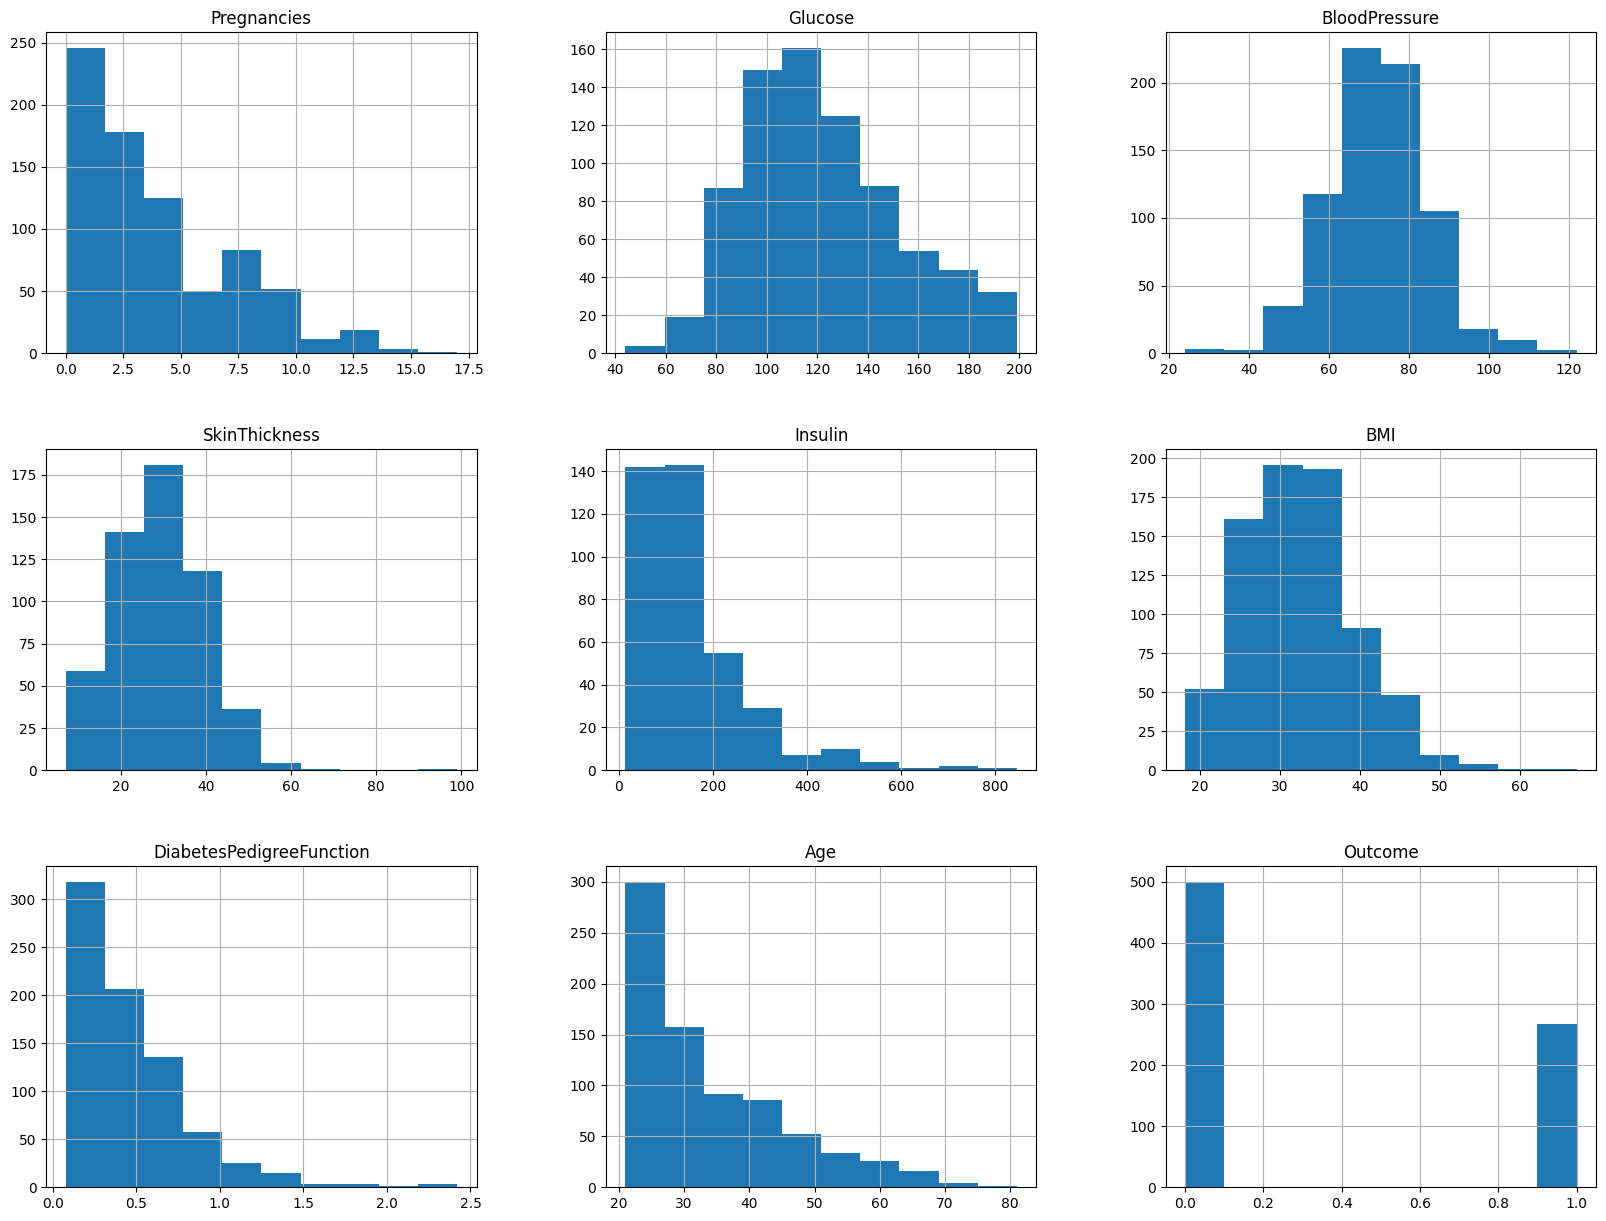

In [11]:
data_copy.hist(figsize=(20, 15))

Visualizamos la distribución de la variable objetivo con un gráfico de barras:

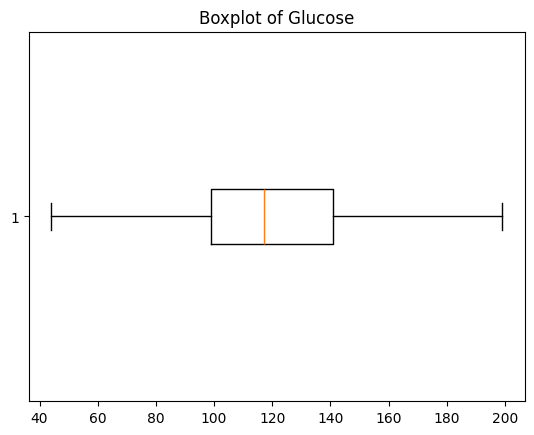

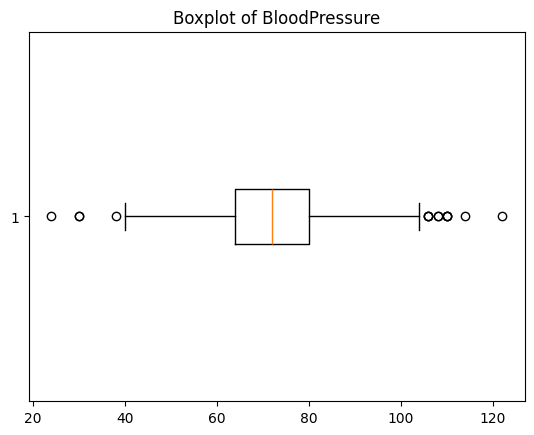

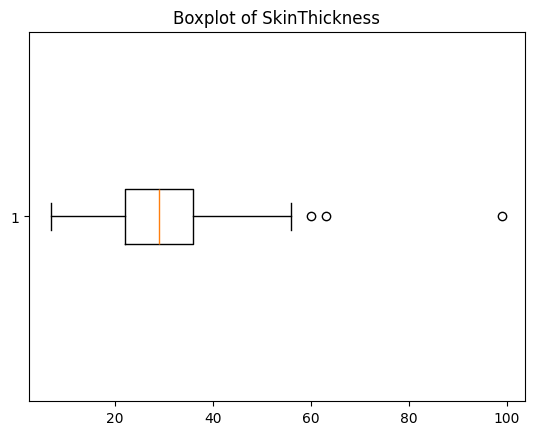

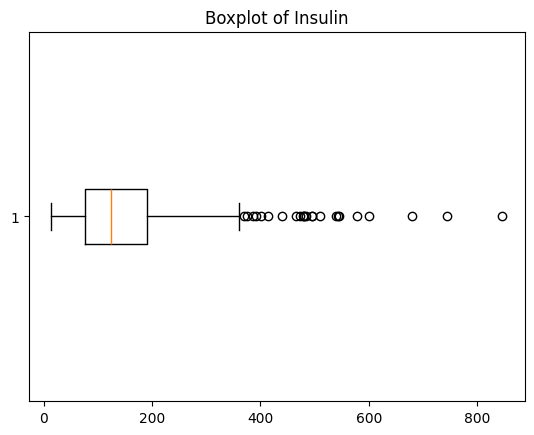

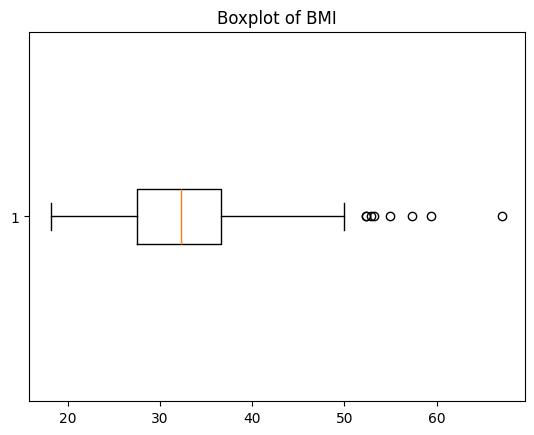

In [12]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols:
    plt.boxplot(data_copy[col].dropna(), vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()

Generamos histogramas para todas las características numéricas:

In [13]:
data_copy['Glucose'] = data_copy['Glucose'].fillna(data_copy['Glucose'].mean())
data_copy['BloodPressure'] = data_copy['BloodPressure'].fillna(data_copy['BloodPressure'].median())
data_copy['SkinThickness'] = data_copy['SkinThickness'].fillna(data_copy['SkinThickness'].median())
data_copy['Insulin'] = data_copy['Insulin'].fillna(data_copy['Insulin'].median())
data_copy['BMI'] = data_copy['BMI'].fillna(data_copy['BMI'].median())


Creamos una matriz de gráficos para visualizar la distribución de cada característica seleccionada:

In [14]:
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


Calculamos la matriz de correlación entre todas las características:

In [15]:
data_copy.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Mostramos las primeras características con mayor correlación con la variable objetivo (Outcome):

## Correlacion de variables

<Axes: >

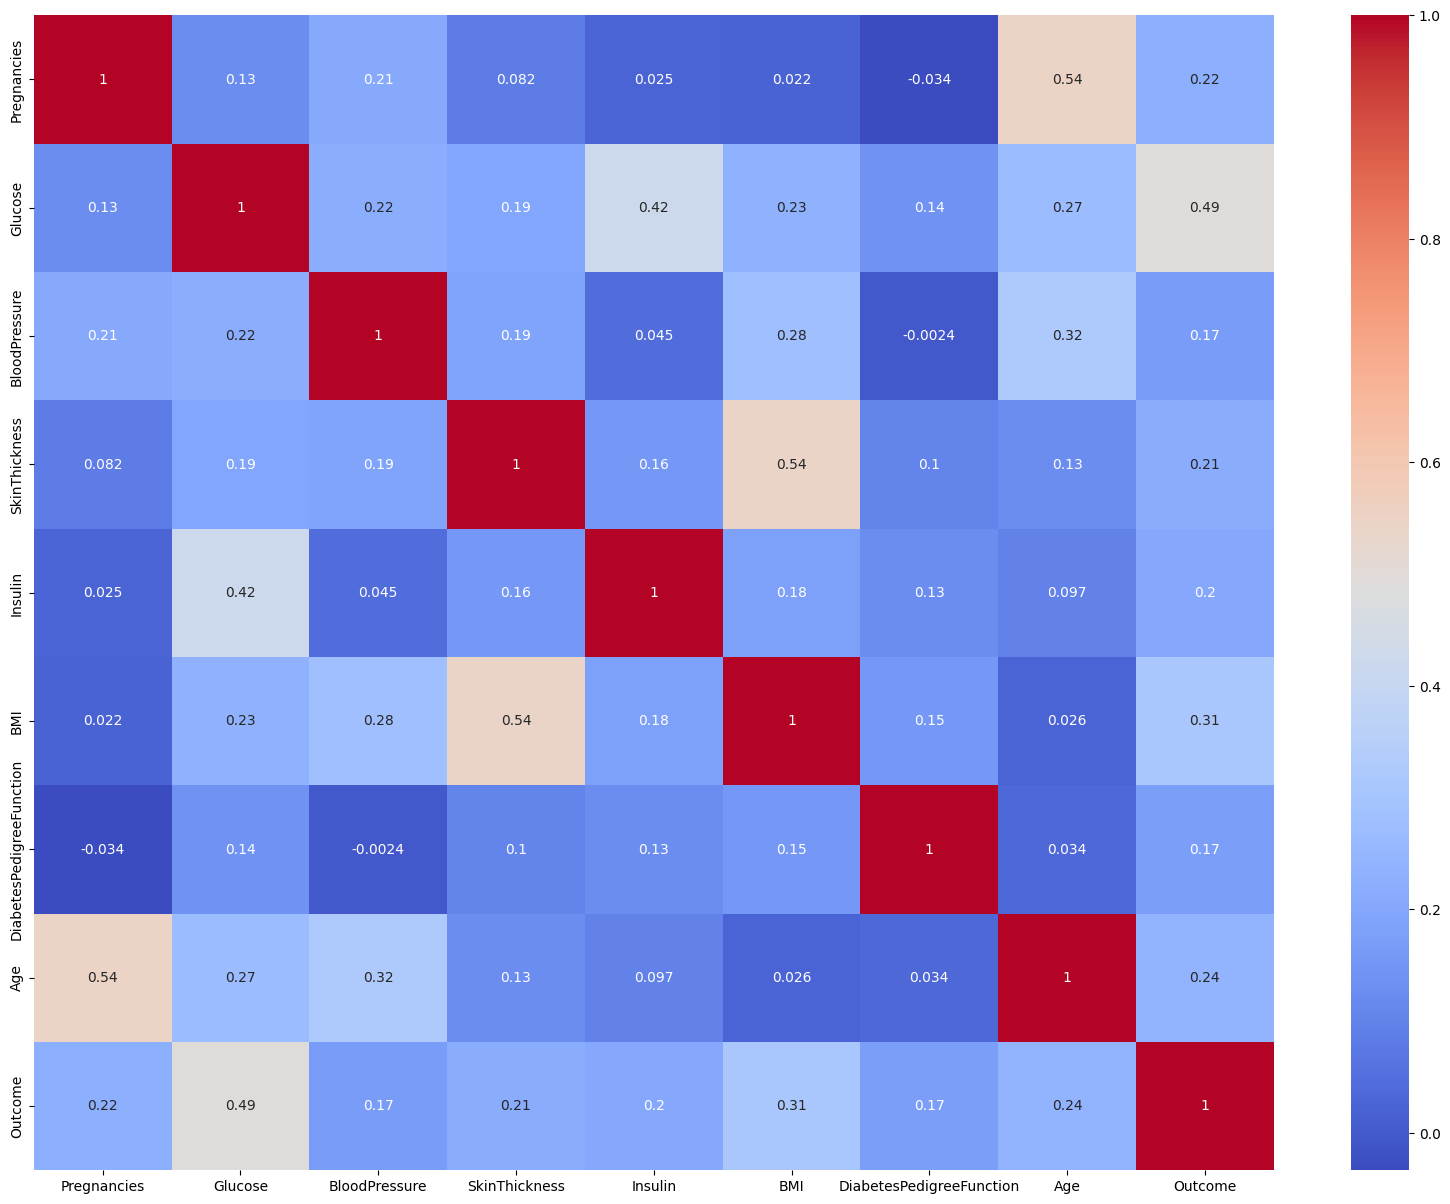

In [16]:
plt.figure(figsize=(20, 15))
sns.heatmap(data_copy.corr(), annot=True, cmap='coolwarm')

Visualizamos un heatmap (mapa de calor) de la matriz de correlación para identificar relaciones entre variables:

In [17]:
X = data_copy.drop('Outcome', axis=1).values
y = data_copy['Outcome'].values

## 4. Preparación de Datos

Separamos las características (X) de la variable objetivo (y):

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


Dividimos los datos en conjunto de entrenamiento (75%) y prueba (25%):
- random_state=42 para reproducibilidad

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Escalamos (normalizamos) las características para que tengan media 0 y desviación estándar 1:
- Esto es importante para algoritmos sensibles a la escala como KNeighbors
- Entrenamos el escalador con datos de entrenamiento y aplicamos a datos de prueba

In [20]:
from  sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

## 5. Entrenamiento del Modelo KNeighbors

Entrenamos el modelo KNeighborsClassifier con parámetro n_neighbors=5 (utiliza los 5 vecinos más cercanos):

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}') 
print(f'F1 Score: {f1:.2f}')

Precision: 0.60
Recall: 0.67
F1 Score: 0.63


Realizamos predicciones en el conjunto de prueba y evaluamos con múltiples métricas:
- Accuracy: Porcentaje general de aciertos
- Precision: De los predichos como positivos, ¿cuántos fueron correctos?
- Recall: De los positivos reales, ¿cuántos detectamos?
- F1 Score: Media armónica entre precision y recall

In [22]:
test_f1 = []
test_pre = []
test_rec = []
test_score = []

for i in range(1, 16):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    test_f1.append(round(f1_score(y_test, y_pred) * 100, 2))
    test_pre.append(round(precision_score(y_test, y_pred) * 100, 2))
    test_rec.append(round(recall_score(y_test, y_pred) * 100, 2))
    test_score.append(round(knn.score(X_test, y_test) * 100, 2))

Iteramos sobre diferentes valores de k (número de vecinos) para encontrar el mejor:
- Evaluamos cada valor de k usando cross-validation
- Guardamos las métricas (precision, recall, f1, accuracy) para cada valor

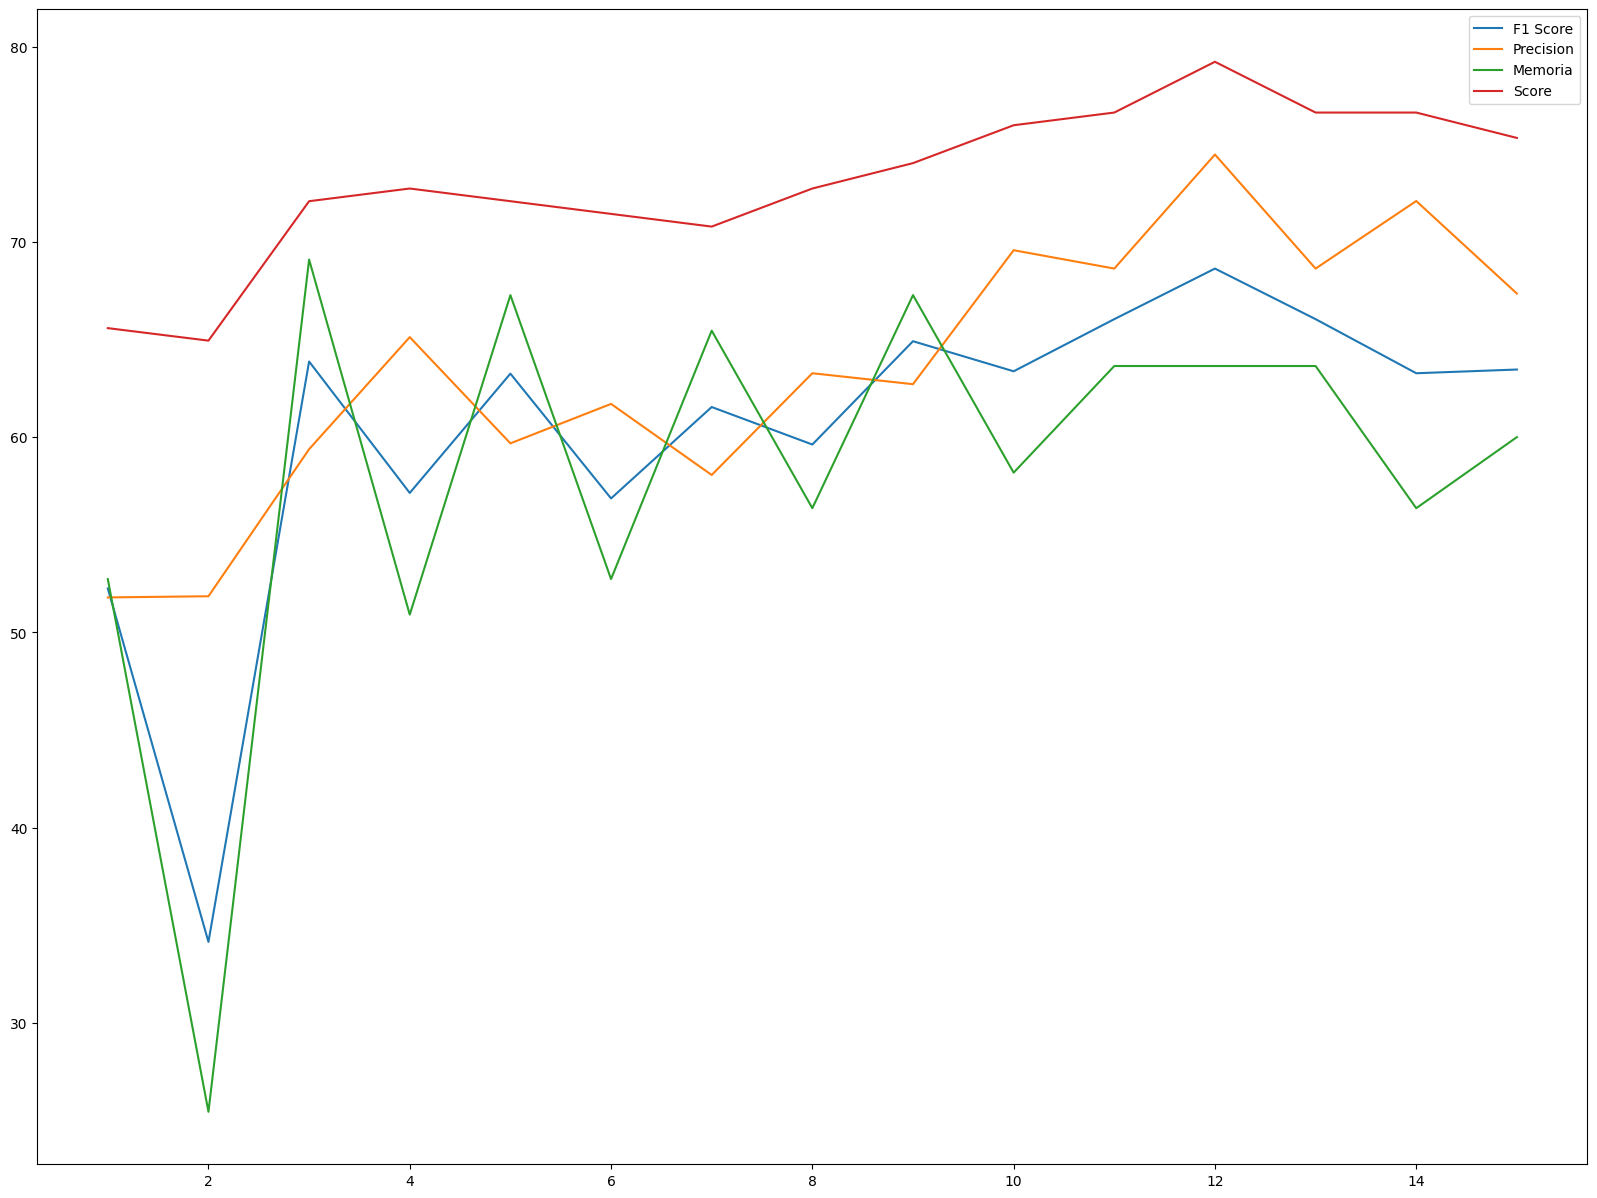

In [23]:
plt.figure(figsize=(20, 15))
plt.plot(range(1, 16), test_f1, label= 'F1 Score')
plt.plot(range(1, 16), test_pre, label= 'Precision')
plt.plot(range(1, 16), test_rec, label= 'Memoria')
plt.plot(range(1, 16), test_score, label= 'Score')

plt.legend()
plt.show()

Visualizamos cómo varían las métricas (F1 Score, Precision, Recall) según el valor de k:
- Esto nos ayuda a identificar el número óptimo de vecinos

## Metricas avanzadas

#### Experimentacion cruzada 

In [24]:
from sklearn.model_selection import cross_val_score

for i in range(1, 16):
    knn = KNeighborsClassifier(i)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    
    print('KNN', i)
    print('scores: ', scores)
    print('Accuracy: %0.2f (+/-%0.2f)' % (scores.mean(), scores.std() * 2))

KNN 1
scores:  [0.67479675 0.66666667 0.67479675 0.77235772 0.72131148]
Accuracy: 0.70 (+/-0.08)
KNN 2
scores:  [0.69105691 0.70731707 0.72357724 0.75609756 0.73770492]
Accuracy: 0.72 (+/-0.05)
KNN 3
scores:  [0.67479675 0.73170732 0.69105691 0.71544715 0.78688525]
Accuracy: 0.72 (+/-0.08)
KNN 4
scores:  [0.72357724 0.75609756 0.69105691 0.73170732 0.76229508]
Accuracy: 0.73 (+/-0.05)
KNN 5
scores:  [0.70731707 0.75609756 0.72357724 0.76422764 0.77868852]
Accuracy: 0.75 (+/-0.05)
KNN 6
scores:  [0.70731707 0.77235772 0.67479675 0.77235772 0.76229508]
Accuracy: 0.74 (+/-0.08)
KNN 7
scores:  [0.73170732 0.80487805 0.68292683 0.76422764 0.78688525]
Accuracy: 0.75 (+/-0.09)
KNN 8
scores:  [0.73170732 0.78861789 0.69918699 0.7804878  0.80327869]
Accuracy: 0.76 (+/-0.08)
KNN 9
scores:  [0.74796748 0.76422764 0.69918699 0.79674797 0.77868852]
Accuracy: 0.76 (+/-0.07)
KNN 10
scores:  [0.70731707 0.79674797 0.69918699 0.77235772 0.78688525]
Accuracy: 0.75 (+/-0.08)
KNN 11
scores:  [0.70731707 0

## 6. Búsqueda de Hiperparámetros (Random Search)

Utilizamos RandomizedSearchCV para optimizar automáticamente los hiperparámetros del modelo KNeighbors:
- Definimos una distribución de parámetros a probar
- Búsqueda aleatoria prueba diferentes combinaciones
- Realizamos validación cruzada para evaluar cada combinación

## RandomizedSearchCV

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_neighbors': np.arange(1, 16),
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()
random_search = RandomizedSearchCV(knn, param_dist, n_iter=10, cv=5)
random_search.fit(X_train, y_train)

print('Best Parameters:', random_search.best_params_)
print('Best Score:', random_search.best_score_)

Best Parameters: {'weights': 'distance', 'n_neighbors': np.int64(14)}
Best Score: 0.7638944422231108


Realizamos la búsqueda aleatoria de hiperparámetros:
- n_iter=20: Prueba 20 combinaciones aleatorias de parámetros
- cv=5: Validación cruzada con 5 folds
- Muestra los mejores parámetros encontrados

## Conclusiones

En este análisis hemos:

1. **Explorado el dataset de diabetes** - Identificamos 768 pacientes con 8 características médicas
2. **Preparado los datos** - Manejo de valores faltantes y escalado de características
3. **Entrenado modelo KNeighbors** - Evaluamos su rendimiento en datos de prueba
4. **Optimizado hiperparámetros** - Probamos diferentes valores de k y usamos Random Search
5. **Evaluado rendimiento** - Utilizando múltiples métricas: Precision, Recall, F1 Score, Accuracy

**Hallazgos clave:**
- La elección del valor k es crítica para el rendimiento del modelo
- El escalado de características es esencial para KNeighbors
- La búsqueda aleatoria de hiperparámetros ayuda a encontrar la mejor configuración